## EXPLORATORY DATA ANALSYSIS (EDA)
# BomaMicro Finance -Credit Risk & Default Prediction engine

In [1]:
#Importing the required libraries for exploratory data analysis (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


print("libraries imported successfully")

libraries imported successfully


Loading the dataset so as we can do summary statistics of the dataset

In [2]:
#loading dataset

df = pd.read_csv('boma_loans_raw.csv')



In [3]:
# displaying the first 10 rows of the dataset

df.head(10)

,customer_id,age,region,monthly_income_tzs,loan_amount_tzs,mobile_money_tx_30d,previous_defaults,days_late_avg,is_default
0,TZ-LOAN-10000,56.00,Dar es Salaam,394283.97,50000,19,2,4.58,0
1,TZ-LOAN-10001,69.00,Mbeya,792609.68,50000,29,0,1.92,0
2,TZ-LOAN-10002,46.00,Dodoma,839736.26,100000,21,0,8.93,0
3,TZ-LOAN-10003,32.00,Dodoma,507746.55,1000000,18,0,4.58,0
4,TZ-LOAN-10004,60.00,Mwanza,418468.41,250000,24,0,6.16,0
5,TZ-LOAN-10005,25.00,Dar es Salaam,1132856.20,1000000,29,0,0.61,0
6,TZ-LOAN-10006,38.00,Dar es Salaam,718248.76,500000,29,0,1.55,0
7,TZ-LOAN-10007,56.00,Dodoma,840790.33,1000000,22,0,28.52,0
8,TZ-LOAN-10008,36.00,Arusha,403377.20,1000000,22,0,2.84,1
9,TZ-LOAN-10009,40.00,Dodoma,284214.66,500000,22,0,2.22,0


In [4]:
#displaying the last 10 rows of the dataset
df.tail(10)

,customer_id,age,region,monthly_income_tzs,loan_amount_tzs,mobile_money_tx_30d,previous_defaults,days_late_avg,is_default
9990,TZ-LOAN-19990,44.00,Arusha,676808.22,1000000,22,2,1.98,1
9991,TZ-LOAN-19991,35.00,Mbeya,945370.95,250000,17,0,4.66,0
9992,TZ-LOAN-19992,41.00,Dar es Salaam,834231.74,100000,25,0,0.06,0
9993,TZ-LOAN-19993,54.00,Mwanza,542047.86,50000,24,0,2.28,0
9994,TZ-LOAN-19994,150.00,Dodoma,918755.26,1000000,26,0,0.01,0
9995,TZ-LOAN-19995,55.00,Arusha,677444.00,500000,19,0,0.90,0
9996,TZ-LOAN-19996,51.00,Dar es Salaam,618160.40,250000,28,0,2.97,0
9997,TZ-LOAN-19997,57.00,Mbeya,507140.25,100000,28,0,3.83,0
9998,TZ-LOAN-19998,64.00,Mbeya,699805.65,1500000,23,0,0.83,0
9999,TZ-LOAN-19999,32.00,Dar es Salaam,948938.78,250000,23,0,6.84,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  str    
 1   age                  10000 non-null  float64
 2   region               10000 non-null  str    
 3   monthly_income_tzs   9506 non-null   float64
 4   loan_amount_tzs      10000 non-null  int64  
 5   mobile_money_tx_30d  10000 non-null  int64  
 6   previous_defaults    10000 non-null  int64  
 7   days_late_avg        9700 non-null   float64
 8   is_default           10000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 703.3 KB


In [6]:
df.describe()

,age,monthly_income_tzs,loan_amount_tzs,mobile_money_tx_30d,previous_defaults,days_late_avg,is_default
count,10000.00,9506.00,10000.00,10000.00,10000.00,9700.00,10000.00
mean,44.06,641509.12,572895.00,24.95,0.38,4.98,0.18
std,16.66,311164.62,520056.84,4.96,0.74,4.89,0.38
min,18.00,-500996.66,50000.00,8.00,0.00,0.00,0.00
25%,31.00,438420.45,100000.00,21.00,0.00,1.46,0.00
50%,43.00,644963.83,500000.00,25.00,0.00,3.52,0.00
75%,57.00,850198.33,1000000.00,28.00,1.00,6.98,0.00
max,150.00,1708716.56,1500000.00,44.00,3.00,40.39,1.00


In [7]:
print(f"shape: {df.shape[0]: ,} rows and {df.shape[1]: ,} columns")
print(f"Memory footprint: {df.memory_usage(deep=True).sum()/1024:.1f} KB\n")

shape:  10,000 rows and  9 columns
Memory footprint: 1701.9 KB



# Data quality audit: missingness

In [8]:
missing_values = df.isnull().sum()
missing = missing_values
pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'n_missing': missing, 'pct_missing': pct}).query('n_missing > 0')
missing_summary

,n_missing,pct_missing
monthly_income_tzs,494,4.94
days_late_avg,300,3.00


In [9]:
for col in ['monthly_income_tzs', 'days_late_avg']:
    default_rate_by_missing = df.groupby(df[col].isna())['is_default'].mean()
    print(f"\n{col} - default rate when missing vs present:")
    print(default_rate_by_missing)


monthly_income_tzs - default rate when missing vs present:
monthly_income_tzs
False   0.18
True    0.21
Name: is_default, dtype: float64

days_late_avg - default rate when missing vs present:
days_late_avg
False   0.18
True    0.18
Name: is_default, dtype: float64


CHECKING THE INVALID DATA INSIDE THE DATASET

In [11]:
#checking negative values in monthly_income_tzs column
print("Negative income rows:", (df['monthly_income_tzs'] < 0).sum())
print(df.loc[df['monthly_income_tzs'] < 0, 'monthly_income_tzs'].describe())

Negative income rows: 251
count       251.00
mean    -127648.07
std       81644.68
min     -500996.66
25%     -150000.00
50%     -150000.00
75%      -63960.27
max       -2664.63
Name: monthly_income_tzs, dtype: float64


In [17]:
#Checking the impossible values which is greater than normal in age column
print("\nAge > 100 (implausible):", (df['age'] > 100))
print(df.loc[df['age']>100, 'age'].value_counts())


Age > 100 (implausible): 0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Name: age, Length: 10000, dtype: bool
age
150.00    50
Name: count, dtype: int64


In [14]:
#checking the duplication in customer_id
print("\nDuplicate customer_id:", df['customer_id'].duplicated().sum())
print("Full-row duplicates:", df.duplicated().sum())




Duplicate customer_id: 0
Full-row duplicates: 0


In [15]:
print("\nDefault rate — negative-income rows:", df.loc[df['monthly_income_tzs'] < 0, 'is_default'].mean())
print("Default rate — age=150 rows:        ", df.loc[df['age'] == 150, 'is_default'].mean())
print("Default rate — overall population:  ", df['is_default'].mean())


Default rate — negative-income rows: 0.06374501992031872
Default rate — age=150 rows:         0.2
Default rate — overall population:   0.18


TARGET VARIABLE: CLASS IMBALANCE


/tmp/ipykernel_27224/1559288988.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Default (n=8,200)', 'Default (n=1,800)'])


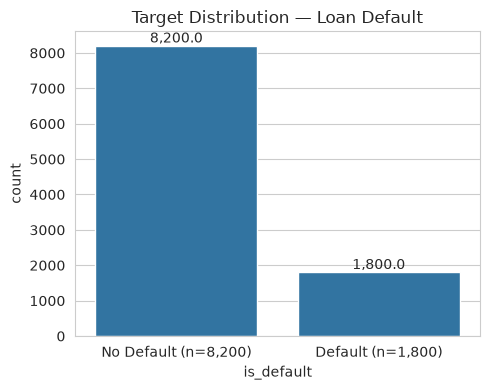

Imbalance ratio: 4.56 : 1


In [18]:
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x='is_default', data=df, ax=ax)
ax.set_title('Target Distribution — Loan Default')
ax.set_xticklabels(['No Default (n=8,200)', 'Default (n=1,800)'])
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

imbalance_ratio = (df['is_default']==0).sum() / (df['is_default']==1).sum()
print(f"Imbalance ratio: {imbalance_ratio:.2f} : 1")

UNINVARIATE DISTRIBUTIONS(numeric)


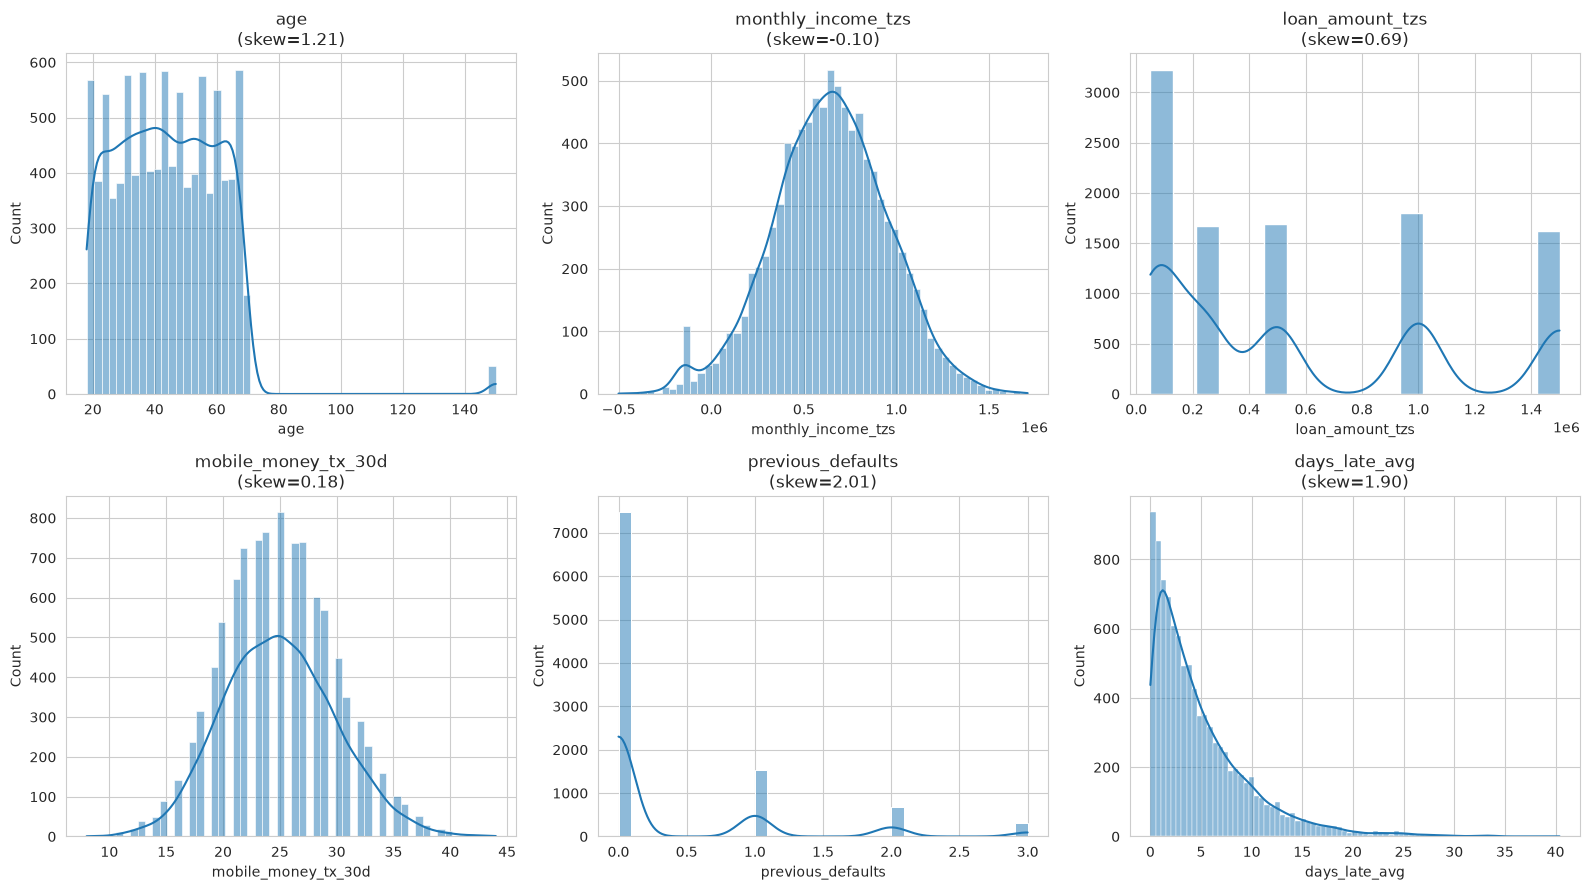

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
cols = ['age', 'monthly_income_tzs', 'loan_amount_tzs', 'mobile_money_tx_30d', 'previous_defaults', 'days_late_avg']

for col, ax in zip(cols, axes.flatten()):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    skew = df[col].dropna().skew()
    ax.set_title(f"{col}\n(skew={skew:.2f})")
plt.tight_layout()
plt.show()